In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, json, math, random
from pathlib import Path

PROJECT_NAME = "CSE499B_Lightweight_Diffusion"
ROOT = Path("/content/drive/MyDrive")/PROJECT_NAME
CKPT_DIR = ROOT/"checkpoints_phase2"
SAMPLE_DIR = ROOT/"samples_phase2"
RESULT_DIR = ROOT/"results_phase2"
CONFIG_DIR = ROOT/"configs_phase2"

for d in [CKPT_DIR, SAMPLE_DIR, RESULT_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("CKPT_DIR:", CKPT_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)
print("RESULT_DIR:", RESULT_DIR)

Mounted at /content/drive
ROOT: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion
CKPT_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints_phase2
SAMPLE_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples_phase2
RESULT_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2


In [2]:
!pip -q install torchmetrics torchvision tqdm einops torch-fidelity thop pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.3 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm
from einops import rearrange
import pandas as pd

def seed_all(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
def get_dataloaders(cfg):
    ds = cfg["dataset"]
    img_size = cfg["image_size"]
    bs = cfg["batch_size"]

    if ds == "CIFAR10":
        channels = 3
        tfm = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x*2 - 1)  # [-1,1]
        ])
        trainset = datasets.CIFAR10(root="/content/data", train=True, download=True, transform=tfm)
    else:
        raise ValueError("This Phase 2 notebook is set for CIFAR10 only.")

    loader = DataLoader(trainset, batch_size=bs, shuffle=True,
                        num_workers=cfg["num_workers"], pin_memory=True, drop_last=True)
    return loader, channels

def denorm(x):
    return (x.clamp(-1,1) + 1) * 0.5

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [5]:
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device
        self.betas = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0)

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.sqrt_alphas_cumprod[t].view(-1,1,1,1)
        b = self.sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1)
        return a * x0 + b * noise, noise

def timestep_embedding(t, dim=256):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, dtype=torch.float32) / half).to(t.device)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0,1))
    return emb

In [6]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=k, padding=p, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.GroupNorm(8, out_ch)
    def forward(self, x):
        return self.bn(self.pw(self.dw(x)))

def conv3x3(in_ch, out_ch, use_depthwise=False):
    if use_depthwise:
        return DepthwiseSeparableConv(in_ch, out_ch, k=3, p=1)
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.GroupNorm(8, out_ch),
    )

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, use_depthwise=False):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, use_depthwise)
        self.conv2 = conv3x3(out_ch, out_ch, use_depthwise)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(tdim, out_ch))
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.conv1(x))
        h = h + self.time_mlp(t_emb).view(-1, h.shape[1], 1, 1)
        h = self.act(self.conv2(h))
        return h + self.skip(x)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch*3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b,c,h,w = x.shape
        x0 = x
        x = self.norm(x)
        qkv = self.qkv(x)
        q,k,v = qkv.chunk(3, dim=1)
        q = rearrange(q, "b c h w -> b (h w) c")
        k = rearrange(k, "b c h w -> b c (h w)")
        v = rearrange(v, "b c h w -> b (h w) c")
        attn = torch.softmax((q @ k) / math.sqrt(c), dim=-1)
        out = attn @ v
        out = rearrange(out, "b (h w) c -> b c h w", h=h, w=w)
        return x0 + self.proj(out)

class UNet(nn.Module):
    def __init__(
        self,
        in_ch=3,
        base_ch=128,
        channel_mults=(1,2,2,2),
        stage_widths=None,      # PSC: e.g., [0.75, 1.0, 1.0, 1.0]
        use_attn=True,
        use_depthwise=False,
        tdim=256
    ):
        super().__init__()
        self.tdim = tdim
        self.time_embed = nn.Sequential(
            nn.Linear(tdim, tdim*4), nn.SiLU(), nn.Linear(tdim*4, tdim)
        )

        if stage_widths is None:
            stage_widths = [1.0] * len(channel_mults)
        assert len(stage_widths) == len(channel_mults)

        chs = [int(base_ch*m*w) for (m, w) in zip(channel_mults, stage_widths)]
        self.chs = chs

        self.in_conv = nn.Conv2d(in_ch, chs[0], 3, padding=1)

        # Down
        self.downs = nn.ModuleList()
        self.attn_down = nn.ModuleList()
        inC = chs[0]
        for outC in chs:
            self.downs.append(ResBlock(inC, outC, tdim, use_depthwise))
            self.downs.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_down.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            inC = outC
        self.downsample = nn.ModuleList([nn.Conv2d(chs[i], chs[i], 4, 2, 1) for i in range(len(chs)-1)])

        # Mid
        midC = chs[-1]
        self.mid1 = ResBlock(midC, midC, tdim, use_depthwise)
        self.mid_attn = SelfAttention2d(midC) if use_attn else nn.Identity()
        self.mid2 = ResBlock(midC, midC, tdim, use_depthwise)

        # Up
        self.upsample = nn.ModuleList(
            [nn.ConvTranspose2d(chs[i+1], chs[i+1], 4, 2, 1) for i in range(len(chs)-1)][::-1]
        )
        self.ups = nn.ModuleList()
        self.attn_up = nn.ModuleList()
        for i in reversed(range(len(chs))):
            outC = chs[i]
            self.ups.append(ResBlock(midC + outC, outC, tdim, use_depthwise))
            self.ups.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_up.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            midC = outC

        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_conv = nn.Conv2d(chs[0], in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = timestep_embedding(t, self.tdim)
        t_emb = self.time_embed(t_emb)

        h = self.in_conv(x)
        skips = []
        ds_idx = 0

        for i in range(len(self.attn_down)):
            h = self.downs[2*i](h, t_emb)
            h = self.downs[2*i+1](h, t_emb)
            h = self.attn_down[i](h)
            skips.append(h)
            if i < len(self.attn_down)-1:
                h = self.downsample[ds_idx](h)
                ds_idx += 1

        h = self.mid1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        us_idx = 0
        for i in range(len(self.attn_up)):
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = self.ups[2*i](h, t_emb)
            h = self.ups[2*i+1](h, t_emb)
            h = self.attn_up[i](h)
            if i < len(self.attn_up)-1:
                h = self.upsample[us_idx](h)
                us_idx += 1

        h = F.silu(self.out_norm(h))
        return self.out_conv(h)

In [7]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

In [8]:
@torch.no_grad()
def ddim_sample(model, diff, shape, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(shape, device=diff.device)

    times = torch.linspace(0, diff.T-1, ddim_steps, device=diff.device).long()
    times = list(reversed(times.tolist()))

    for idx, i in enumerate(tqdm(times, desc="DDIM sampling")):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        alpha_bar = diff.alphas_cumprod[i]
        x0 = (x - torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha_bar)

        if idx == len(times)-1:
            x = x0
            break

        j = times[idx+1]
        alpha_bar_next = diff.alphas_cumprod[j]

        sigma = eta * torch.sqrt((1-alpha_bar_next)/(1-alpha_bar)) * torch.sqrt(1 - alpha_bar/alpha_bar_next)
        noise = torch.randn_like(x) if sigma > 0 else 0.0

        x = torch.sqrt(alpha_bar_next)*x0 + torch.sqrt(1-alpha_bar_next - sigma**2)*eps + sigma*noise

    return x

In [9]:
from thop import profile
from torchmetrics.image.fid import FrechetInceptionDistance

@torch.no_grad()
def benchmark_sampling(cfg, sampler_model, diff, n_images=64, repeats=3):
    sampler_model.eval()
    shape = (n_images, cfg["channels"], cfg["image_size"], cfg["image_size"])

    # warmup
    _ = ddim_sample(sampler_model, diff, shape, cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"])

    times = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        t0 = time.time()
        _ = ddim_sample(sampler_model, diff, shape, cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"])
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    return (sum(times)/len(times))/n_images

@torch.no_grad()
def compute_fid(cfg, sampler_model, diff, n_real=2000, n_fake=2000):
    loader, _ = get_dataloaders(cfg)
    fid = FrechetInceptionDistance(feature=2048).to(device)

    # Real
    seen = 0
    for x, _ in loader:
        x = x.to(device)
        x01 = (denorm(x)*255).clamp(0,255).to(torch.uint8)
        fid.update(x01, real=True)
        seen += x.size(0)
        if seen >= n_real:
            break

    # Fake
    bs = cfg["batch_size"]
    made = 0
    while made < n_fake:
        cur = min(bs, n_fake - made)
        fake = ddim_sample(sampler_model, diff,
                           (cur, cfg["channels"], cfg["image_size"], cfg["image_size"]),
                           cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"])
        fake01 = (denorm(fake)*255).clamp(0,255).to(torch.uint8)
        fid.update(fake01, real=False)
        made += cur

    return float(fid.compute().item())

def compute_flops(cfg, model):
    model.eval()
    x = torch.randn(1, cfg["channels"], cfg["image_size"], cfg["image_size"]).to(device)
    t = torch.zeros(1, dtype=torch.long, device=device)
    macs, params = profile(model, inputs=(x, t), verbose=False)
    # THOP returns MACs; many report FLOPs ~ 2*MACs for conv, but we keep MACs as is.
    return float(macs), float(params)

In [10]:
def ckpt_path(exp_name, epoch):
    return CKPT_DIR/f"{exp_name}_epoch{epoch}.pt"

def save_ckpt(exp_name, epoch, model, opt, ema, cfg):
    payload = {
        "epoch": epoch,
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "ema": ema.shadow if ema is not None else None,
        "cfg": cfg
    }
    torch.save(payload, ckpt_path(exp_name, epoch))

def try_load_latest(exp_name):
    pts = sorted(CKPT_DIR.glob(f"{exp_name}_epoch*.pt"))
    if not pts:
        return None
    return pts[-1]

def build_model_from_cfg(cfg):
    m = cfg["model"]
    model = UNet(
        in_ch=cfg["channels"],
        base_ch=int(m["base_channels"]),
        channel_mults=tuple(m["channel_mults"]),
        stage_widths=m.get("stage_widths", None),
        use_attn=m["use_attn"],
        use_depthwise=m["use_depthwise"],
        tdim=256
    ).to(device)
    return model

def train_experiment(exp_name, cfg):
    loader, channels = get_dataloaders(cfg)
    cfg["channels"] = channels

    diff = Diffusion(cfg["T"], cfg["beta_start"], cfg["beta_end"], device=device)
    model = build_model_from_cfg(cfg)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"])

    ema = EMA(model, decay=cfg["ema"]["decay"]) if cfg["ema"]["use"] else None

    # resume if exists
    latest = try_load_latest(exp_name)
    start_epoch = 1
    if latest is not None:
        ckpt = torch.load(latest, map_location=device)
        model.load_state_dict(ckpt["model"])
        opt.load_state_dict(ckpt["opt"])
        if ema is not None and ckpt["ema"] is not None:
            ema.shadow = ckpt["ema"]
        start_epoch = ckpt["epoch"] + 1
        print(f"[{exp_name}] Resuming from {latest.name} (next epoch={start_epoch})")

    log = []
    for epoch in range(start_epoch, cfg["epochs"]+1):
        model.train()
        torch.cuda.reset_peak_memory_stats()
        t0 = time.time()
        avg_loss = 0.0

        pbar = tqdm(loader, desc=f"{exp_name} | epoch {epoch}/{cfg['epochs']}")
        for x, _ in pbar:
            x = x.to(device)
            b = x.size(0)
            t = torch.randint(0, diff.T, (b,), device=device).long()
            xt, noise = diff.q_sample(x, t)
            pred = model(xt, t)
            loss = F.mse_loss(pred, noise)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            if ema is not None:
                ema.update(model)

            avg_loss = 0.99*avg_loss + 0.01*loss.item() if avg_loss != 0 else loss.item()
            pbar.set_postfix(loss=avg_loss)

        epoch_time = time.time() - t0
        peak_mem = torch.cuda.max_memory_allocated()/1024**2 if device == "cuda" else 0.0

        save_ckpt(exp_name, epoch, model, opt, ema, cfg)

        log.append({
            "exp": exp_name,
            "epoch": epoch,
            "loss": float(avg_loss),
            "epoch_time_sec": float(epoch_time),
            "peak_mem_mb": float(peak_mem),
            "params_m": float(count_params(model)/1e6),
        })

        # periodic samples (epoch 1 and every 20 epochs + last)
        if epoch == 1 or epoch % 20 == 0 or epoch == cfg["epochs"]:
            sampler = build_model_from_cfg(cfg)
            if ema is not None:
                ema.copy_to(sampler)
            else:
                sampler.load_state_dict(model.state_dict())
            n = cfg["sample"]["n_samples"]
            samp = ddim_sample(sampler, diff, (n, cfg["channels"], cfg["image_size"], cfg["image_size"]),
                               cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"])
            grid = utils.make_grid(denorm(samp), nrow=cfg["sample"]["grid_rows"])
            out = SAMPLE_DIR/f"{exp_name}_epoch{epoch}_ddim.png"
            utils.save_image(grid, out)
            print("Saved sample:", out)

        # save training log progressively
        with open(RESULT_DIR/f"{exp_name}_trainlog.json", "w") as f:
            json.dump(log, f, indent=2)

    return model, ema, diff, cfg

In [11]:
BASE = {
    "dataset": "CIFAR10",
    "image_size": 32,
    "channels": 3,
    "batch_size": 128,
    "num_workers": 2,
    "T": 1000,
    "beta_start": 1e-4,
    "beta_end": 0.02,
    "epochs": 100,            # Phase 2 target
    "lr": 2e-4,
    "ema": {"use": True, "decay": 0.999},
    "sample": {"n_samples": 64, "grid_rows": 8, "ddim_steps": 50, "ddim_eta": 0.0},
    "model": {
        "base_channels": 128,
        "channel_mults": [1,2,2,2],
        "stage_widths": None,
        "use_attn": True,
        "use_depthwise": False,
    }
}

import copy
EXPS = {}

# 1) Baseline-100
EXPS["baseline_100"] = copy.deepcopy(BASE)

# 2) DepthReduce-100 (your best from ablation)
EXPS["depth_reduce_100"] = copy.deepcopy(BASE)
EXPS["depth_reduce_100"]["model"]["channel_mults"] = [1,2,2]

# 3) PSC v1: compress shallow stage only
EXPS["pscA_shallow075"] = copy.deepcopy(BASE)
EXPS["pscA_shallow075"]["model"]["stage_widths"] = [0.75, 1.0, 1.0, 1.0]

# 4) PSC v2: progressive widths
EXPS["pscB_progressive"] = copy.deepcopy(BASE)
EXPS["pscB_progressive"]["model"]["stage_widths"] = [0.75, 0.9, 1.0, 1.0]

# 5) PSC v3: keep deep attention only (simple variant)
EXPS["pscC_noattn"] = copy.deepcopy(BASE)
EXPS["pscC_noattn"]["model"]["use_attn"] = False
EXPS["pscC_noattn"]["model"]["stage_widths"] = [0.75, 1.0, 1.0, 1.0]

# Save configs to Drive
for k, v in EXPS.items():
    with open(CONFIG_DIR/f"{k}.json", "w") as f:
        json.dump(v, f, indent=2)

list(EXPS.keys())

['baseline_100',
 'depth_reduce_100',
 'pscA_shallow075',
 'pscB_progressive',
 'pscC_noattn']

In [12]:
# ✅ Phase 2: Load previously trained models from Google Drive
# Your checkpoints from the earlier run are already saved in Drive.
# This cell loads the epoch-100 checkpoints and (optionally) replays the saved training logs


import json, re
from pathlib import Path

# Use ONLY these two experiments for Phase 2 comparison
RUN_LIST = ["baseline_100", "depth_reduce_100"]

def find_latest_epoch_ckpt(exp_name, ckpt_dir):
    # Matches: exp_epoch{N}.pt
    pats = list(Path(ckpt_dir).glob(f"{exp_name}_epoch*.pt"))
    if not pats:
        return None, None
    def get_ep(p):
        m = re.search(r"_epoch(\d+)\.pt$", p.name)
        return int(m.group(1)) if m else -1
    pats = sorted(pats, key=get_ep)
    return pats[-1], get_ep(pats[-1])

def load_for_eval(exp_name, ckpt_dir, preferred_epoch=100):
    # Prefer epoch=100 if it exists, otherwise load latest available.
    p = Path(ckpt_dir)/f"{exp_name}_epoch{preferred_epoch}.pt"
    if not p.exists():
        p, ep = find_latest_epoch_ckpt(exp_name, ckpt_dir)
        if p is None:
            raise FileNotFoundError(f"No checkpoint found for {exp_name} in {ckpt_dir}")
        print(f"[{exp_name}] epoch{preferred_epoch} not found → loading latest: {p.name}")
    else:
        ep = preferred_epoch
        print(f"[{exp_name}] loading: {p.name}")

    ckpt = torch.load(p, map_location=device)
    cfg = ckpt["cfg"]
    diff = Diffusion(cfg["T"], cfg["beta_start"], cfg["beta_end"], device=device)

    model = build_model_from_cfg(cfg)
    model.load_state_dict(ckpt["model"])

    ema = EMA(model, decay=cfg["ema"]["decay"]) if cfg["ema"]["use"] else None
    if ema is not None and ckpt.get("ema") is not None:
        ema.shadow = ckpt["ema"]

    return model, ema, diff, cfg, ep

trained = {}

# Load models from Drive checkpoints
for name in RUN_LIST:
    model, ema, diff, cfg_used, loaded_epoch = load_for_eval(name, CKPT_DIR, preferred_epoch=100)
    trained[name] = {"model": model, "ema": ema, "diff": diff, "cfg": cfg_used, "loaded_epoch": loaded_epoch}

print("\nLoaded models:", {k: v["loaded_epoch"] for k, v in trained.items()})

# ---- Optional: replay training log (if available) to show training progress ----
def replay_training_log(exp_name):
    log_path = RESULT_DIR/f"{exp_name}_trainlog.json"
    if not log_path.exists():
        print(f"[{exp_name}] training log not found: {log_path}")
        return None

    with open(log_path) as f:
        logs = json.load(f)

    print(f"\n[{exp_name}] Replaying logged training progress (from saved trainlog):")
    first = logs[0]["loss"]
    last  = logs[-1]["loss"]
    print(f"First logged epoch loss: {first}")
    print(f"Last  logged epoch loss: {last}")
    return logs

logs_baseline = replay_training_log("baseline_100")
logs_depthred = replay_training_log("depth_reduce_100")


[baseline_100] loading: baseline_100_epoch100.pt
[depth_reduce_100] epoch100 not found → loading latest: depth_reduce_100_epoch51.pt

Loaded models: {'baseline_100': 100, 'depth_reduce_100': 51}

[baseline_100] Replaying logged training progress (from saved trainlog):
First logged epoch loss: 0.07139605976892067
Last  logged epoch loss: 0.029669811976809252

[depth_reduce_100] Replaying logged training progress (from saved trainlog):
First logged epoch loss: 0.07292451043437943
Last  logged epoch loss: 0.030637018613004705


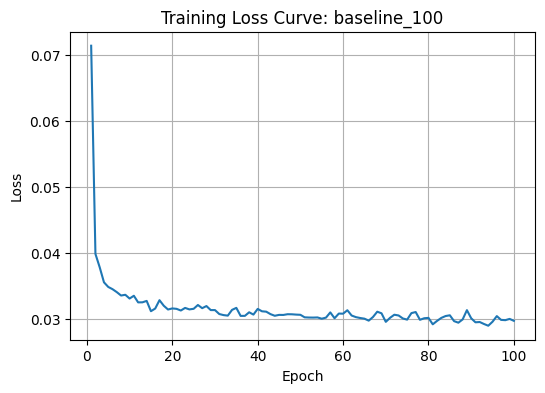

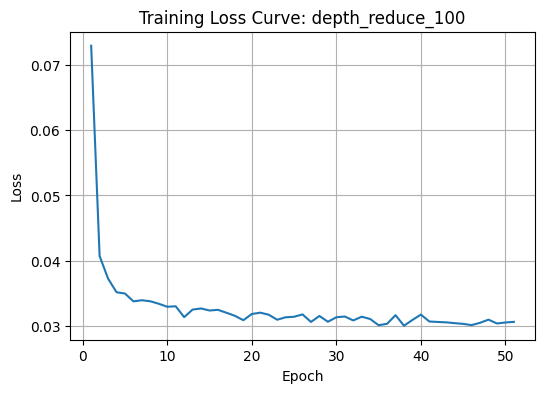

In [13]:
# Plot training loss curves from saved logs (no retraining)
import matplotlib.pyplot as plt
import json

def plot_log(exp_name):
    log_path = RESULT_DIR/f"{exp_name}_trainlog.json"
    if not log_path.exists():
        print(f"No log found for {exp_name}: {log_path}")
        return
    with open(log_path) as f:
        logs = json.load(f)
    epochs = [x["epoch"] for x in logs]
    losses = [x["loss"] for x in logs]
    plt.figure(figsize=(6,4))
    plt.plot(epochs, losses)
    plt.title(f"Training Loss Curve: {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

plot_log("baseline_100")
plot_log("depth_reduce_100")


In [16]:
# evaluation


N_REAL, N_FAKE = 50, 50      # very small for quick trend
DDIM_STEPS = 8              # fewer steps = faster
DO_FID = True               # set False if still too slow
DO_SPEED = False            # CPU speed is not meaningful; keep False

RUN_LIST = ["baseline_100", "depth_reduce_100"]
results = []

for name in RUN_LIST:
    print("\nEVALUATING:", name)

    cfg = trained[name]["cfg"]
    cfg["sample"]["ddim_steps"] = DDIM_STEPS

    model = trained[name]["model"]
    ema = trained[name]["ema"]
    diff = trained[name]["diff"]

    # Build sampler + EMA weights
    sampler = build_model_from_cfg(cfg)
    if ema is not None:
        ema.copy_to(sampler)
    else:
        sampler.load_state_dict(model.state_dict())
    sampler.eval()

    # 1) Save a small qualitative sample grid (good for weekly update)
    with torch.no_grad():
        samp = ddim_sample(sampler, diff, (16, cfg["channels"], cfg["image_size"], cfg["image_size"]),
                           ddim_steps=DDIM_STEPS, eta=cfg["sample"]["ddim_eta"])
    grid_path = SAMPLE_DIR/f"{name}_quick_ddim{DDIM_STEPS}.png"
    from torchvision import utils
    utils.save_image(denorm(samp), grid_path, nrow=4)
    print("Saved quick samples:", grid_path)

    # 2) Tiny FID (optional)
    if DO_FID:
        fid = compute_fid(cfg, sampler, diff, n_real=N_REAL, n_fake=N_FAKE)
    else:
        fid = None

    # 3) Speed (skip on CPU)
    sp = None

    results.append({
        "exp": name,
        "epochs_trained": trained[name]["loaded_epoch"],
        "fid_ddim": None if fid is None else float(fid),
        "sec_per_img_ddim": sp,
        "ddim_steps": DDIM_STEPS,
        "n_real": N_REAL,
        "n_fake": N_FAKE,
        "note": "FAST weekly update (CPU) — not paper-grade"
    })

import pandas as pd
df = pd.DataFrame(results)
display(df)

# Save so later plots won't error
out_csv = RESULT_DIR/"phase2_results.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)


EVALUATING: baseline_100


DDIM sampling:  88%|████████▊ | 7/8 [00:23<00:03,  3.42s/it]


Saved quick samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples_phase2/baseline_100_quick_ddim8.png


DDIM sampling:  88%|████████▊ | 7/8 [01:16<00:10, 10.96s/it]



EVALUATING: depth_reduce_100


DDIM sampling:  88%|████████▊ | 7/8 [00:26<00:03,  3.75s/it]


Saved quick samples: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples_phase2/depth_reduce_100_quick_ddim8.png


DDIM sampling:  88%|████████▊ | 7/8 [01:16<00:10, 10.92s/it]


,exp,epochs_trained,fid_ddim,sec_per_img_ddim,ddim_steps,n_real,n_fake,note
0,baseline_100,100,230.924805,None,8,50,50,FAST weekly update (CPU) — not paper-grade
1,depth_reduce_100,51,231.535599,None,8,50,50,FAST weekly update (CPU) — not paper-grade


Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2/phase2_results.csv


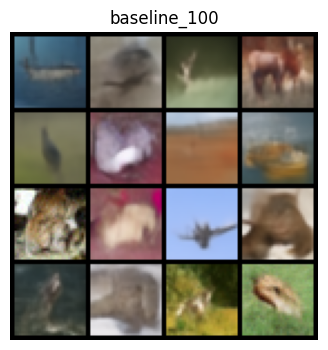

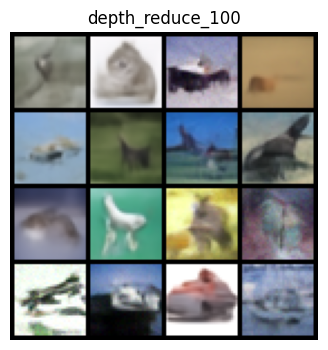

In [17]:
# Show the quick sample images nicely
from PIL import Image
import matplotlib.pyplot as plt

for name in ["baseline_100", "depth_reduce_100"]:
    p = SAMPLE_DIR/f"{name}_quick_ddim8.png"
    if p.exists():
        plt.figure(figsize=(4,4))
        plt.imshow(Image.open(p))
        plt.axis("off")
        plt.title(name)
        plt.show()